In [1]:
import os
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

# load the .env file variables
load_dotenv()

# Get credential values
client_id = os.environ.get("CLIENT_ID")
client_secret = os.environ.get("CLIENT_SECRET")

In [4]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

auth_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)
sp = spotipy.Spotify(auth_manager=auth_manager)

In [5]:

# Kendrick Lamar's Spotify artist ID
artist_id = '2YZyLoL8N0Wb9xBt1NhZWg'

# Fetch top tracks (in the US market, can change to 'global' if needed)
results = sp.artist_top_tracks(artist_id, country='US')

# Display top 10 tracks
print("Top 10 Kendrick Lamar Songs (according to Spotify):\n")
for i, track in enumerate(results['tracks'][:10]):
    name = track['name']
    popularity = track['popularity']
    print(f"{i+1}. {name} (Popularity: {popularity})")

Top 10 Kendrick Lamar Songs (according to Spotify):

1. luther (with sza) (Popularity: 94)
2. Not Like Us (Popularity: 95)
3. All The Stars (with SZA) (Popularity: 95)
4. tv off (feat. lefty gunplay) (Popularity: 94)
5. Money Trees (Popularity: 84)
6. squabble up (Popularity: 90)
7. HUMBLE. (Popularity: 89)
8. 30 For 30 (with Kendrick Lamar) (Popularity: 88)
9. Like That (Popularity: 88)
10. peekaboo (feat. azchike) (Popularity: 87)


In [9]:
import pandas as pd

tracks_data = []

for track in results['tracks']:
    tracks_data.append({
        'Name': track['name'],
        'Popularity': track['popularity'],
        'Duration (ms)': track['duration_ms'] // 1000
    })

df_tracks = pd.DataFrame(tracks_data)


In [8]:
print(type(df_tracks))


<class 'str'>


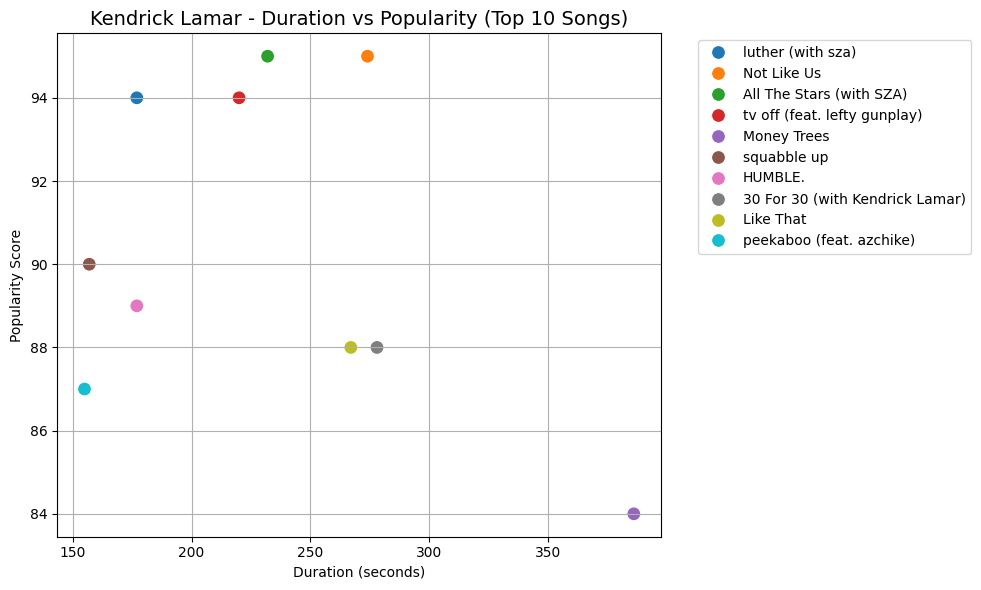

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot: Duration vs Popularity
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_tracks, x='Duration (ms)', y='Popularity', hue='Name', s=100)

plt.title('Kendrick Lamar - Duration vs Popularity (Top 10 Songs)', fontsize=14)
plt.xlabel('Duration (seconds)')
plt.ylabel('Popularity Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()
